# Class Weight Comparison

This notebook evaluates the impact of using **Class Weights** to handle imbalanced data.

We compare three scenarios:
1. **Baseline**: Original features, no class weights
2. **Enhanced**: Feature Engineering, no class weights
3. **Enhanced + Balanced**: Feature Engineering + `class_weight='balanced'`

**Goal**: Improve Recall (sensitivity) for the minority class without generating synthetic data.

In [1]:
import sys
sys.path.append('../src')

from data_preprocessing import preprocess_pipeline
from model_training import train_all_models
from evaluation import evaluate_all_models
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
RANDOM_STATE = 42
DATA_PATH = '../data/raw/hcc_dataset.csv'

## 1. Run Experiments


--- Scenario 1: Baseline ---
HCC DATASET PREPROCESSING PIPELINE
✓ Loaded dataset: 165 rows, 50 columns
✓ Missing values: 1077 → 0 (strategy: median)
✓ Encoded 48 categorical features
✓ Encoded target variable 'Class': {'Dies': np.int64(0), 'Lives': np.int64(1)}
✓ Train-test split: 132 train, 33 test samples
✓ Scaled features using StandardScaler
✓ Preprocessing complete!
  - Features: 49
  - Train samples: 132
  - Test samples: 33
TRAINING ALL MODELS

🌲 Training Random Forest...
✓ Random Forest trained with default parameters (class_weight=None)

🌳 Training Decision Tree...
✓ Decision Tree trained with default parameters (class_weight=None)

👥 Training K-Nearest Neighbors...
✓ KNN trained with default parameters

✓ All 3 models trained successfully!

EVALUATING ALL MODELS

📊 Random Forest Performance:
  Accuracy:  0.6061
  Precision: 0.5922
  Recall:    0.6061
  F1-Score:  0.5941
  ROC AUC:   0.7231

📋 Classification Report - Random Forest
              precision    recall  f1-score  

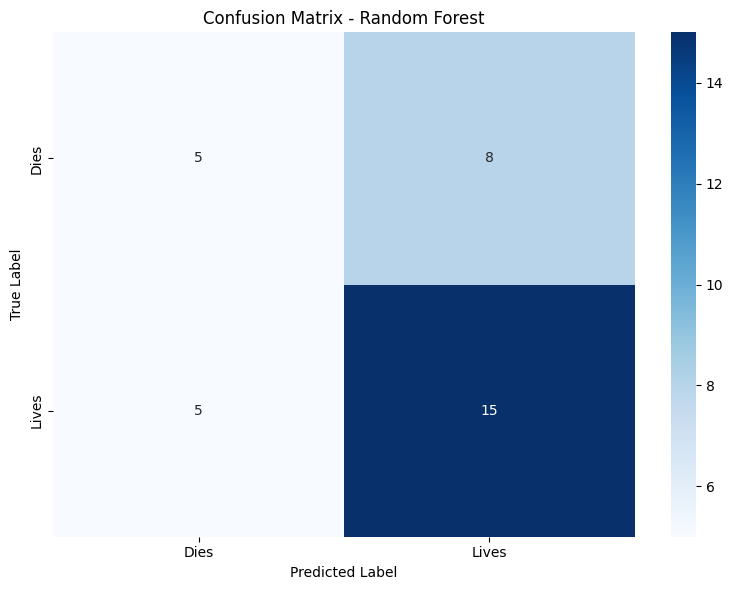

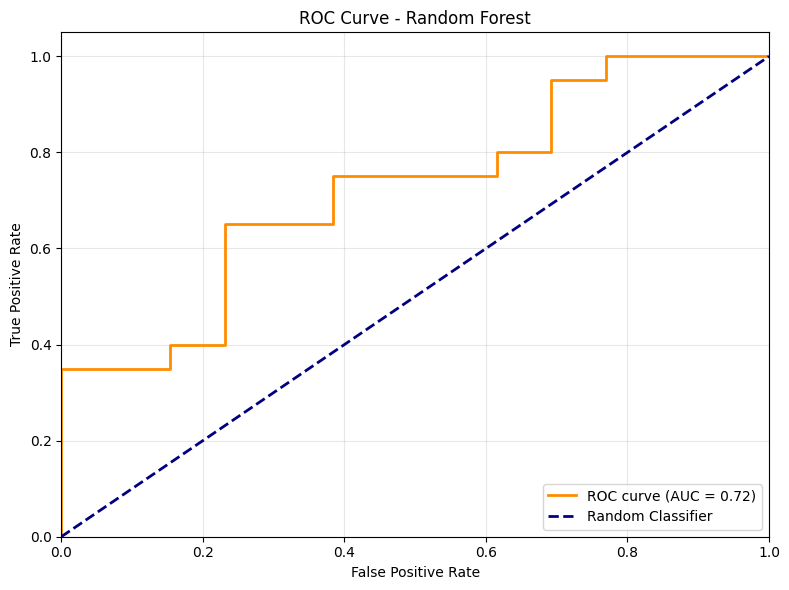


📊 Decision Tree Performance:
  Accuracy:  0.7576
  Precision: 0.7677
  Recall:    0.7576
  F1-Score:  0.7599
  ROC AUC:   0.7538

📋 Classification Report - Decision Tree
              precision    recall  f1-score   support

        Dies       0.67      0.77      0.71        13
       Lives       0.83      0.75      0.79        20

    accuracy                           0.76        33
   macro avg       0.75      0.76      0.75        33
weighted avg       0.77      0.76      0.76        33



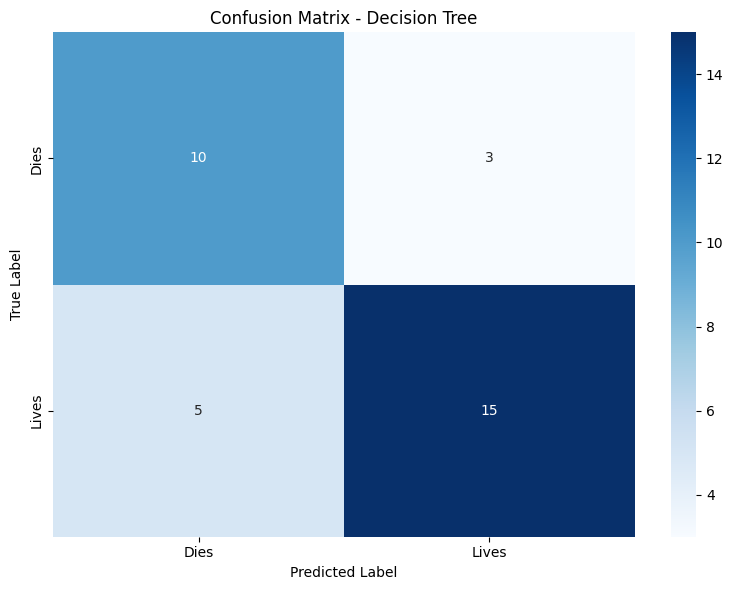

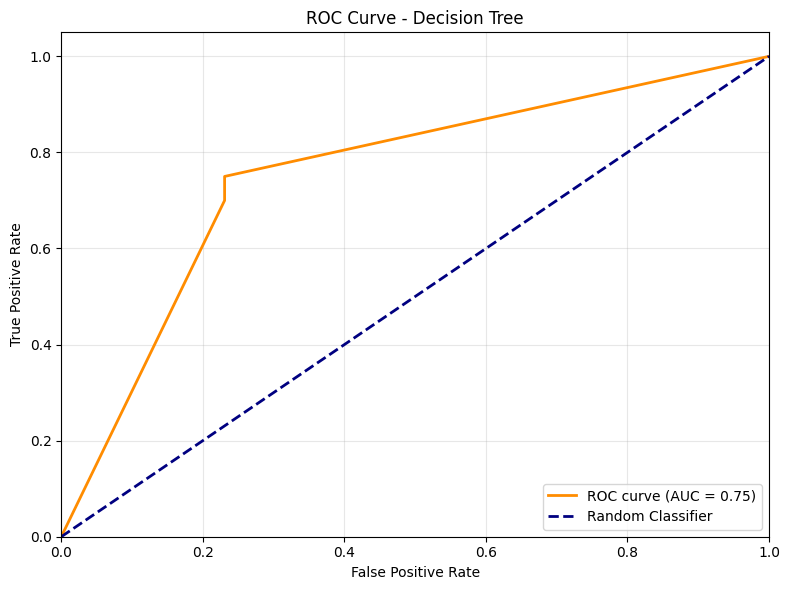


📊 KNN Performance:
  Accuracy:  0.6667
  Precision: 0.6583
  Recall:    0.6667
  F1-Score:  0.6455
  ROC AUC:   0.7308

📋 Classification Report - KNN
              precision    recall  f1-score   support

        Dies       0.62      0.38      0.48        13
       Lives       0.68      0.85      0.76        20

    accuracy                           0.67        33
   macro avg       0.65      0.62      0.62        33
weighted avg       0.66      0.67      0.65        33



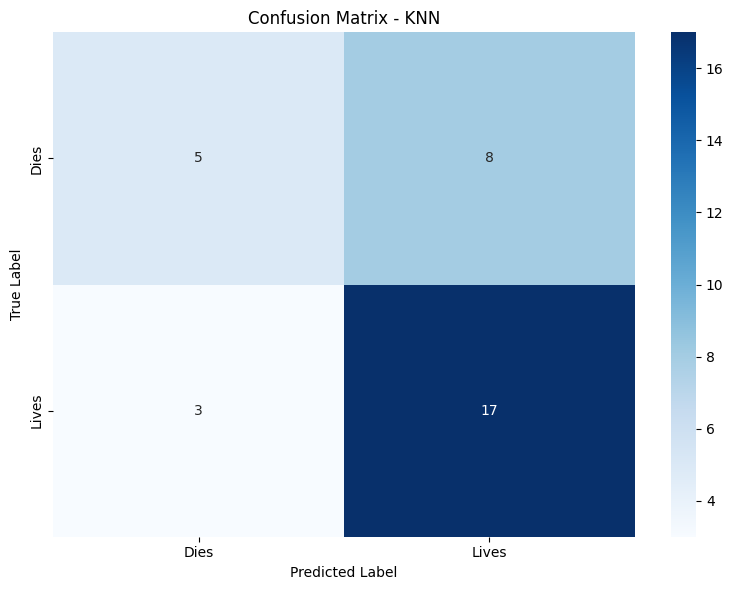

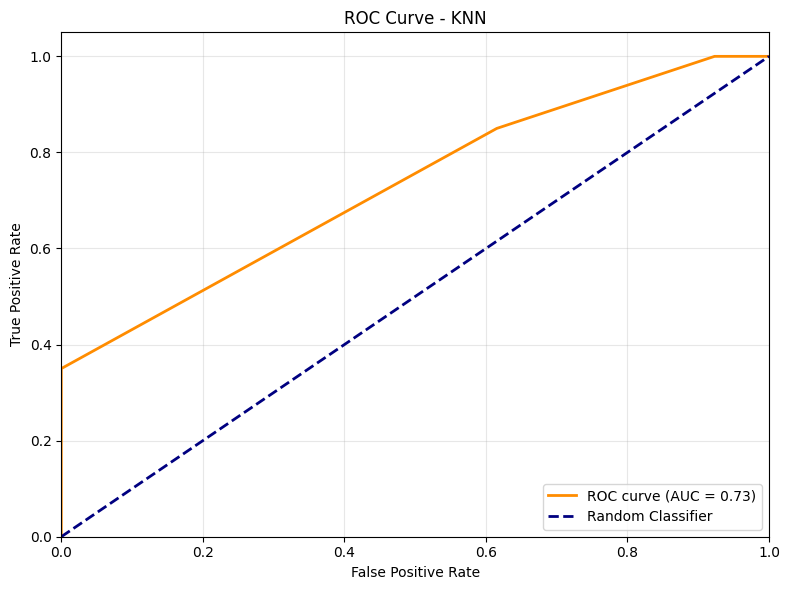


MODEL COMPARISON
        model  accuracy  precision   recall  f1_score  roc_auc
Decision Tree  0.757576   0.767677 0.757576  0.759854 0.753846
          KNN  0.666667   0.658333 0.666667  0.645503 0.730769
Random Forest  0.606061   0.592227 0.606061  0.594111 0.723077

--- Scenario 2: Enhanced Features ---
HCC DATASET PREPROCESSING PIPELINE
✓ Loaded dataset: 165 rows, 50 columns
✓ Missing values: 1077 → 0 (strategy: median)

🛠️ Applying Feature Engineering...
✓ Created interaction features: ['Age_AFP_Interaction', 'Hemo_Iron_Interaction']
✓ Created log-transformed features: ['Log_AFP', 'Log_Creatinine', 'Log_Ferritin', 'Log_AST', 'Log_ALT', 'Log_ALP']
✓ Created binned features: Age_Group, AFP_Level
✓ Feature engineering complete
✓ Encoded 42 categorical features
✓ Encoded target variable 'Class': {'Dies': np.int64(0), 'Lives': np.int64(1)}
✓ Train-test split: 132 train, 33 test samples
✓ Scaled features using StandardScaler
✓ Preprocessing complete!
  - Features: 59
  - Train samples:

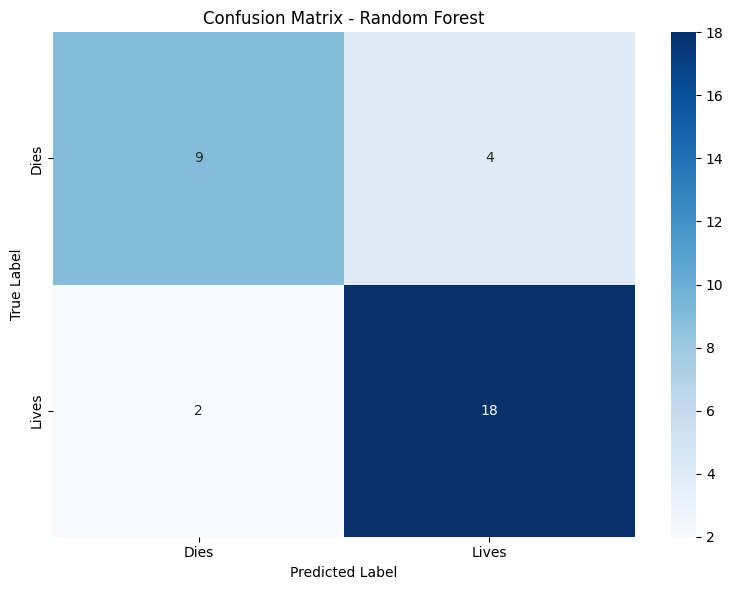

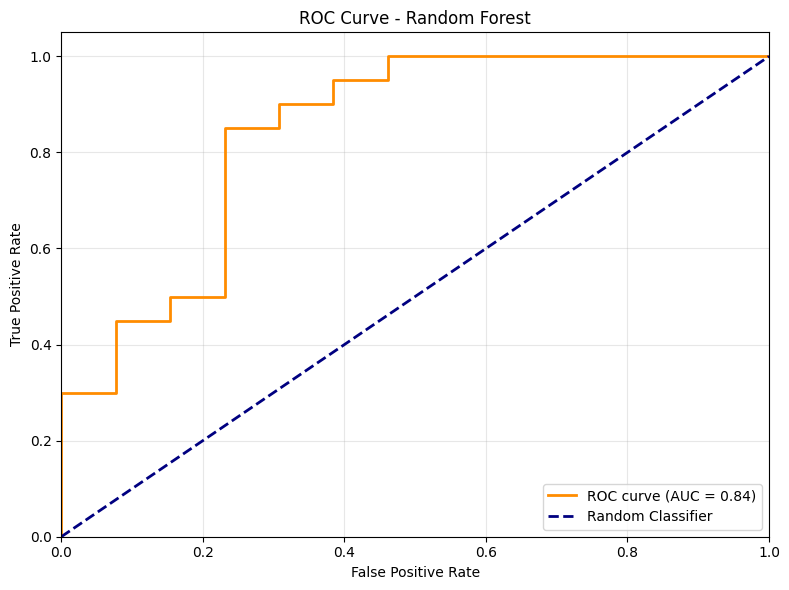


📊 Decision Tree Performance:
  Accuracy:  0.6364
  Precision: 0.6478
  Recall:    0.6364
  F1-Score:  0.6398
  ROC AUC:   0.6308

📋 Classification Report - Decision Tree
              precision    recall  f1-score   support

        Dies       0.53      0.62      0.57        13
       Lives       0.72      0.65      0.68        20

    accuracy                           0.64        33
   macro avg       0.63      0.63      0.63        33
weighted avg       0.65      0.64      0.64        33



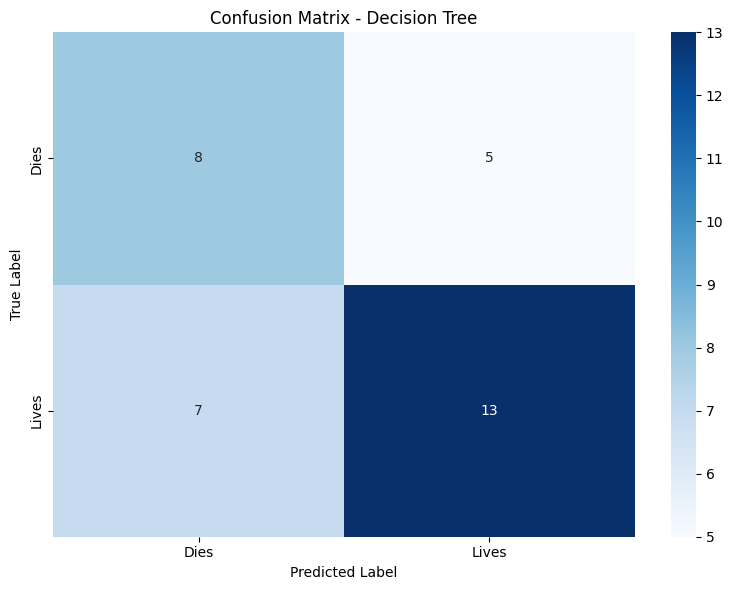

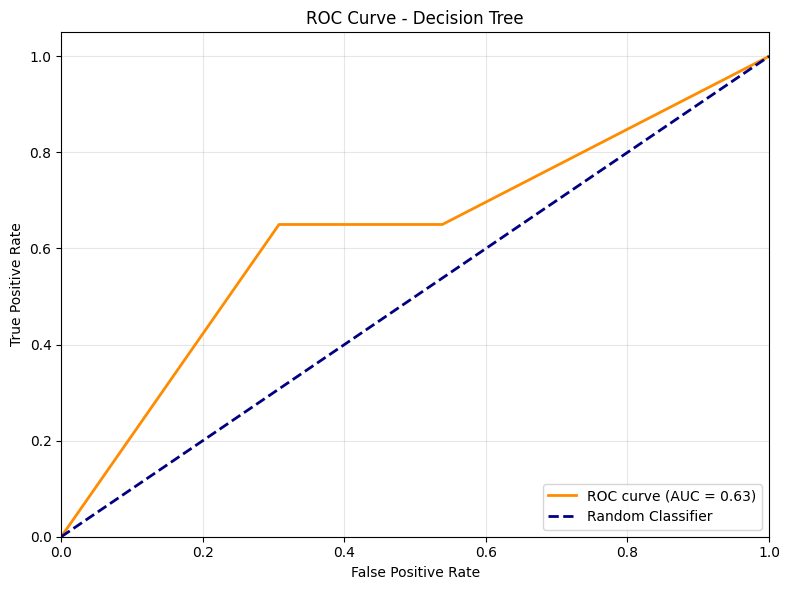


📊 KNN Performance:
  Accuracy:  0.7273
  Precision: 0.7548
  Recall:    0.7273
  F1-Score:  0.6973
  ROC AUC:   0.8212

📋 Classification Report - KNN
              precision    recall  f1-score   support

        Dies       0.83      0.38      0.53        13
       Lives       0.70      0.95      0.81        20

    accuracy                           0.73        33
   macro avg       0.77      0.67      0.67        33
weighted avg       0.75      0.73      0.70        33



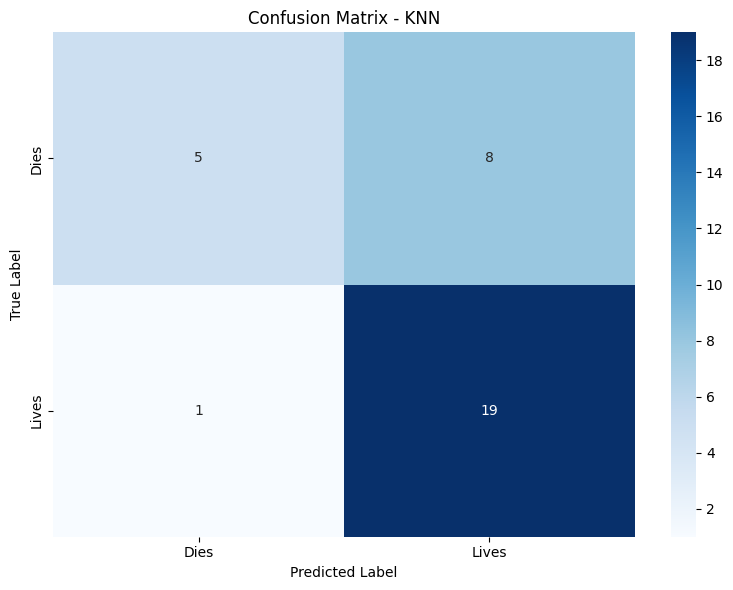

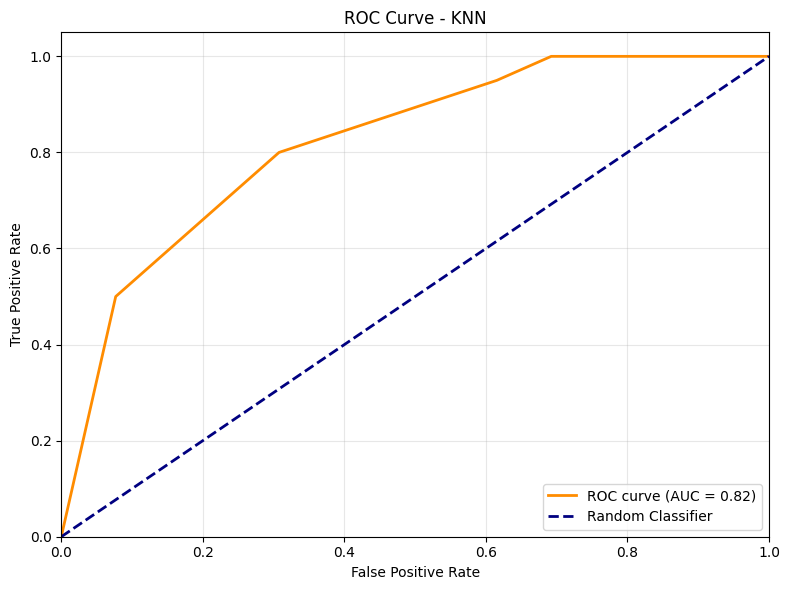


MODEL COMPARISON
        model  accuracy  precision   recall  f1_score  roc_auc
Random Forest  0.818182   0.818182 0.818182  0.814935 0.842308
          KNN  0.727273   0.754770 0.727273  0.697343 0.821154
Decision Tree  0.636364   0.647811 0.636364  0.639781 0.630769

--- Scenario 3: Enhanced + Balanced Weights ---
HCC DATASET PREPROCESSING PIPELINE
✓ Loaded dataset: 165 rows, 50 columns
✓ Missing values: 1077 → 0 (strategy: median)

🛠️ Applying Feature Engineering...
✓ Created interaction features: ['Age_AFP_Interaction', 'Hemo_Iron_Interaction']
✓ Created log-transformed features: ['Log_AFP', 'Log_Creatinine', 'Log_Ferritin', 'Log_AST', 'Log_ALT', 'Log_ALP']
✓ Created binned features: Age_Group, AFP_Level
✓ Feature engineering complete
✓ Encoded 42 categorical features
✓ Encoded target variable 'Class': {'Dies': np.int64(0), 'Lives': np.int64(1)}
✓ Train-test split: 132 train, 33 test samples
✓ Scaled features using StandardScaler
✓ Preprocessing complete!
  - Features: 59
  - Trai

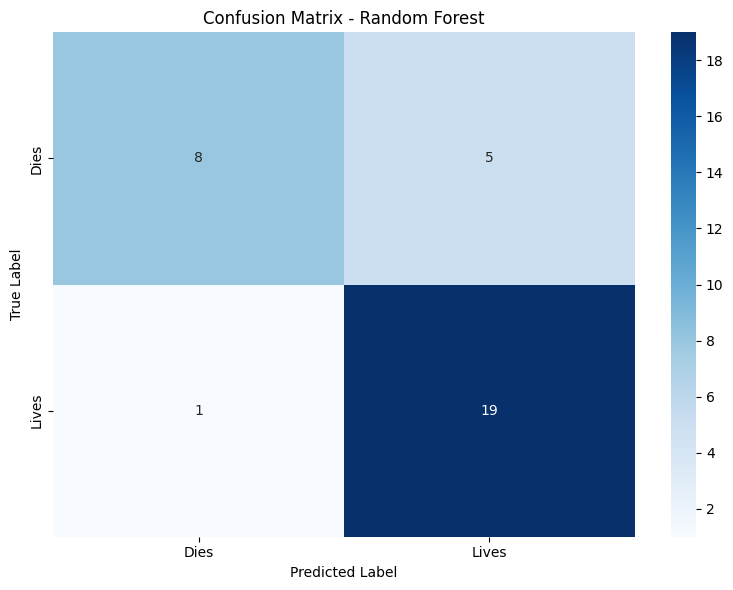

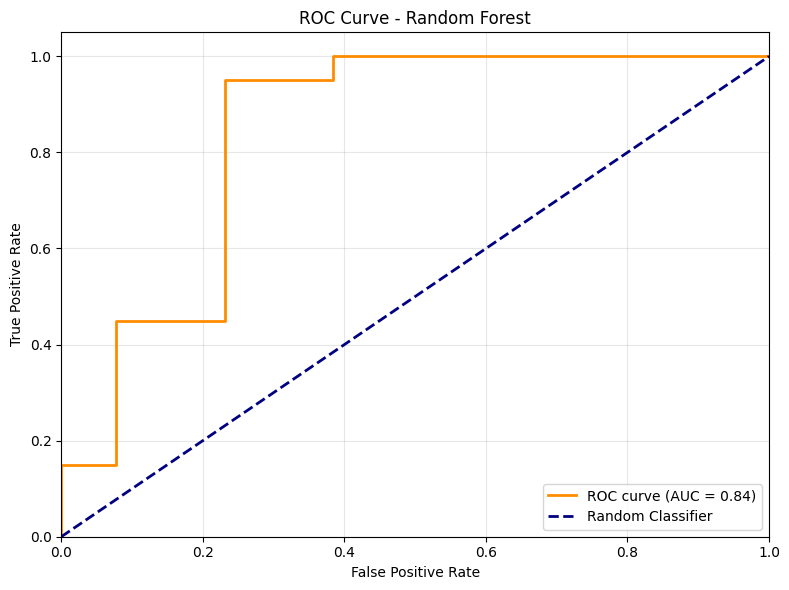


📊 Decision Tree Performance:
  Accuracy:  0.6061
  Precision: 0.5848
  Recall:    0.6061
  F1-Score:  0.5810
  ROC AUC:   0.5538

📋 Classification Report - Decision Tree
              precision    recall  f1-score   support

        Dies       0.50      0.31      0.38        13
       Lives       0.64      0.80      0.71        20

    accuracy                           0.61        33
   macro avg       0.57      0.55      0.55        33
weighted avg       0.58      0.61      0.58        33



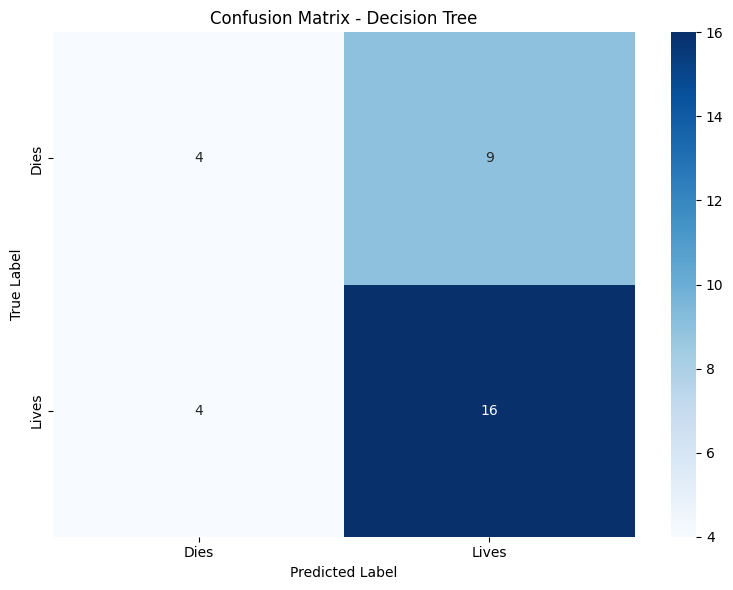

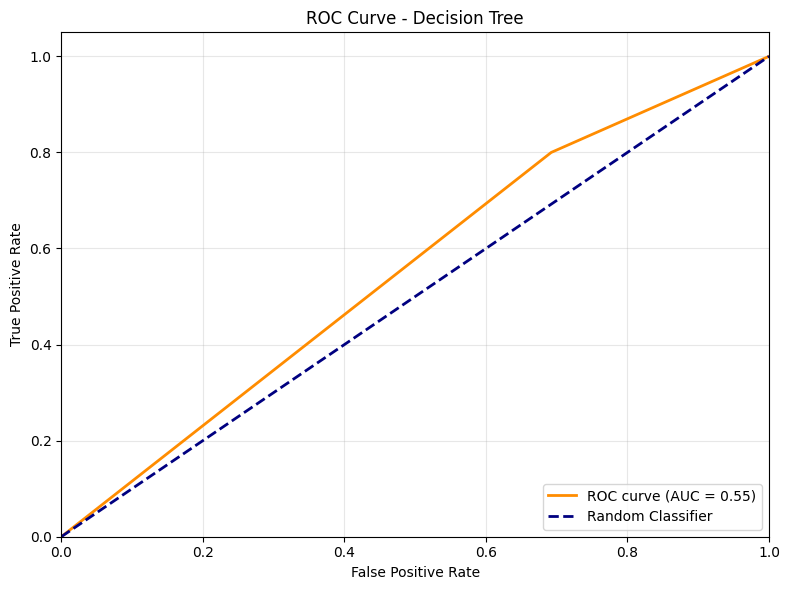


📊 KNN Performance:
  Accuracy:  0.7273
  Precision: 0.7548
  Recall:    0.7273
  F1-Score:  0.6973
  ROC AUC:   0.8212

📋 Classification Report - KNN
              precision    recall  f1-score   support

        Dies       0.83      0.38      0.53        13
       Lives       0.70      0.95      0.81        20

    accuracy                           0.73        33
   macro avg       0.77      0.67      0.67        33
weighted avg       0.75      0.73      0.70        33



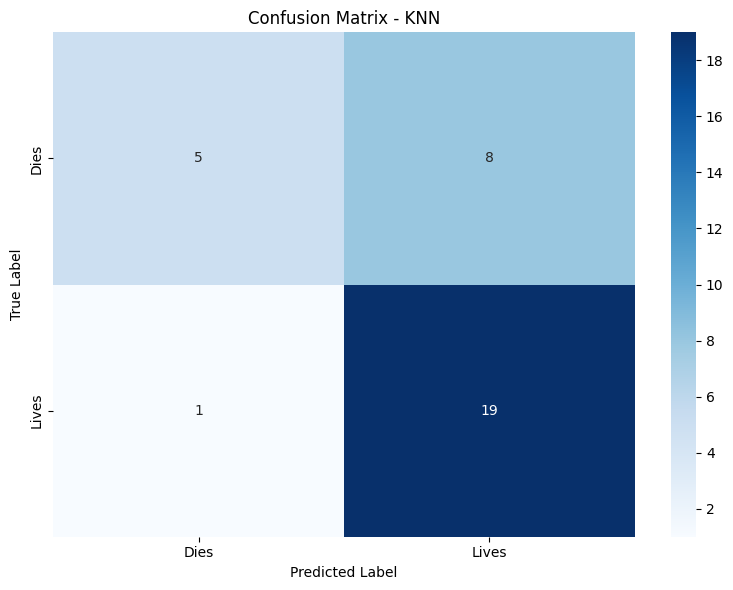

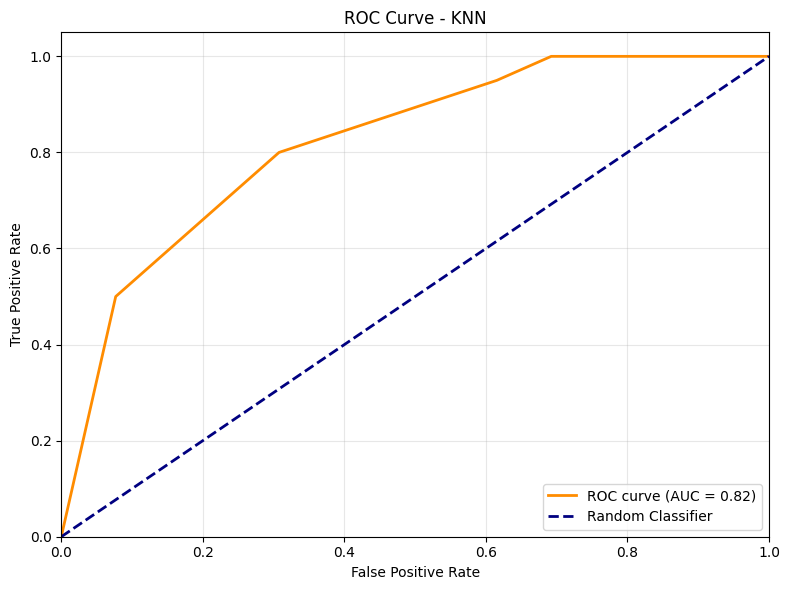


MODEL COMPARISON
        model  accuracy  precision   recall  f1_score  roc_auc
Random Forest  0.818182   0.829966 0.818182  0.809917 0.842308
          KNN  0.727273   0.754770 0.727273  0.697343 0.821154
Decision Tree  0.606061   0.584848 0.606061  0.581049 0.553846


In [2]:
# Scenario 1: Baseline
print("\n--- Scenario 1: Baseline ---")
data_1 = preprocess_pipeline(DATA_PATH, use_feature_engineering=False, random_state=RANDOM_STATE)
models_1 = train_all_models(data_1['X_train'], data_1['y_train'], class_weight=None, random_state=RANDOM_STATE)
res_1 = evaluate_all_models(models_1, data_1['X_test'], data_1['y_test'])
res_1['Scenario'] = 'Baseline'

# Scenario 2: Enhanced Features (Standard Weights)
print("\n--- Scenario 2: Enhanced Features ---")
data_2 = preprocess_pipeline(DATA_PATH, use_feature_engineering=True, random_state=RANDOM_STATE)
models_2 = train_all_models(data_2['X_train'], data_2['y_train'], class_weight=None, random_state=RANDOM_STATE)
res_2 = evaluate_all_models(models_2, data_2['X_test'], data_2['y_test'])
res_2['Scenario'] = 'Enhanced'

# Scenario 3: Enhanced + Balanced Weights
print("\n--- Scenario 3: Enhanced + Balanced Weights ---")
data_3 = preprocess_pipeline(DATA_PATH, use_feature_engineering=True, random_state=RANDOM_STATE)
models_3 = train_all_models(data_3['X_train'], data_3['y_train'], class_weight='balanced', random_state=RANDOM_STATE)
res_3 = evaluate_all_models(models_3, data_3['X_test'], data_3['y_test'])
res_3['Scenario'] = 'Enhanced + Balanced'

## 2. Comparison Results


Random Forest Performance across Scenarios:
              Scenario  accuracy  recall  precision  f1_score
0             Baseline    0.6061  0.6061     0.5922    0.5941
0             Enhanced    0.8182  0.8182     0.8182    0.8149
0  Enhanced + Balanced    0.8182  0.8182     0.8300    0.8099


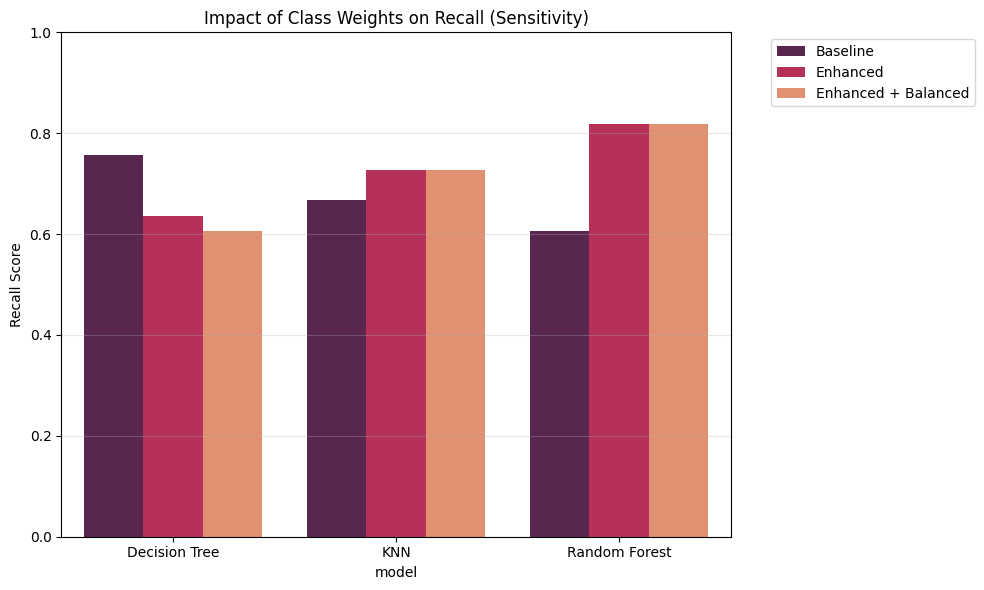

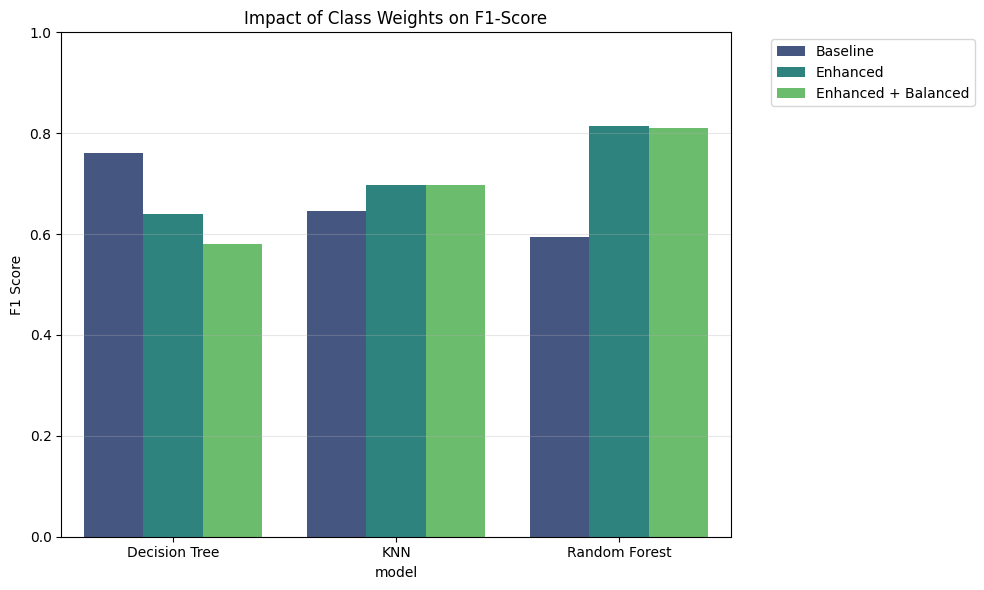

In [3]:
# Combine all results
all_results = pd.concat([res_1, res_2, res_3])

# Filter for Random Forest
rf_results = all_results[all_results['model'] == 'Random Forest']

print("\nRandom Forest Performance across Scenarios:")
print(rf_results[['Scenario', 'accuracy', 'recall', 'precision', 'f1_score']].round(4))

# Plot Recall Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results, x='model', y='recall', hue='Scenario', palette='rocket')
plt.title("Impact of Class Weights on Recall (Sensitivity)")
plt.ylabel("Recall Score")
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Plot F1 Comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=all_results, x='model', y='f1_score', hue='Scenario', palette='viridis')
plt.title("Impact of Class Weights on F1-Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Here it is noticed that the class weight is not that useful to use in this case, since it is not helping the model to learn the minority class.